#Pojeto g2 - Análise Climática das Regiões Brasileiras
#Disciplica: Linguagens de programação

##Introução
Este projeto tem como objetivo analisar dados climáticos de diversas cidades brasileiras entre 2015 e 2025.

Serão avaliadas variáveis como temperatura, chuva, umidade, velocidade do vento e eventos extremos para identificar padrões climáticos e tendências ao longo do tempo.

##Importação das Bibliotecas

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

##Leitura dos Dados

In [ ]:
df = pd.read_csv("simulacao_clima_brasil.csv")

##Visualização Inicial


In [ ]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ano                 4440 non-null   int64  
 1   mes                 4440 non-null   int64  
 2   data                4440 non-null   object 
 3   regiao              4440 non-null   object 
 4   uf                  4440 non-null   object 
 5   cidade              4440 non-null   object 
 6   temperatura_media   4440 non-null   float64
 7   temperatura_maxima  4440 non-null   float64
 8   temperatura_minima  4440 non-null   float64
 9   chuva_mm            4440 non-null   float64
 10  umidade             4440 non-null   float64
 11  velocidade_vento    4440 non-null   float64
 12  eventos_extremos    4440 non-null   int64  
 13  nivel_alerta        4440 non-null   object 
dtypes: float64(6), int64(3), object(5)
memory usage: 485.8+ KB


,ano,mes,temperatura_media,temperatura_maxima,temperatura_minima,chuva_mm,umidade,velocidade_vento,eventos_extremos
count,4440.000000,4440.000000,4440.000000,4440.000000,4440.000000,4440.000000,4440.000000,4440.000000,4440.000000
mean,2019.500000,6.500000,24.993176,30.495360,19.971824,105.895293,66.413851,18.394977,2.008559
std,2.872605,3.452441,3.922671,4.180402,4.111152,60.035600,18.270190,9.687678,1.433019
min,2015.000000,1.000000,11.400000,15.600000,5.700000,4.200000,35.000000,2.000000,0.000000
25%,2017.000000,3.750000,22.400000,27.700000,17.300000,61.500000,50.300000,10.000000,1.000000
50%,2019.500000,6.500000,25.000000,30.400000,19.950000,94.800000,66.550000,18.600000,2.000000
75%,2022.000000,9.250000,27.600000,33.200000,22.700000,140.500000,82.000000,26.900000,3.000000
max,2024.000000,12.000000,39.300000,45.400000,34.300000,491.500000,97.900000,35.000000,9.000000


##Limpeza dos Dados

In [ ]:
df.isnull().sum()

df.duplicated().sum()

np.int64(0)

##Engenharia de Atributos

In [ ]:
df["data"] = pd.to_datetime(df["data"])

df["trimistre"] = df["data"].dt.quarter

def estacao(mes):
  if mes in[12,1,2]:
    return "Verão"
  if mes in[3,4,5]:
    return "Outono"
  if mes in [6,7,8]:
    return "Inverno"
  else:
    return "Primeveira"

df["estacao"] = df["mes"].apply(estacao)

##KPIs

In [ ]:
print("Temperatura Média:", round(df["temperatura_media"].mean(),2))

print("Chuva Total:", round(df["chuva_mm"].sum(),2))

print("Eventos Extremos:", df["eventos_extremos"].sum())

Temperatura Média: 24.99
Chuva Total: 470175.1
Eventos Extremos: 8918


##Análise Exploratório

###Temperatura por Região

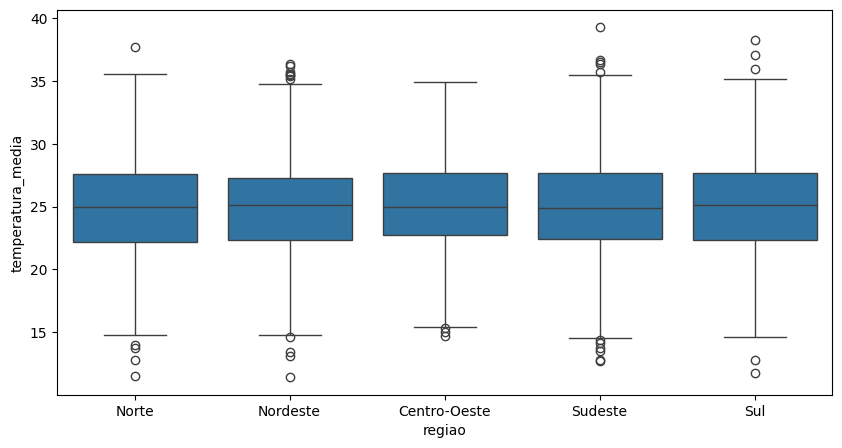

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="regiao", y="temperatura_media")
plt.show()

###Chuva por Região

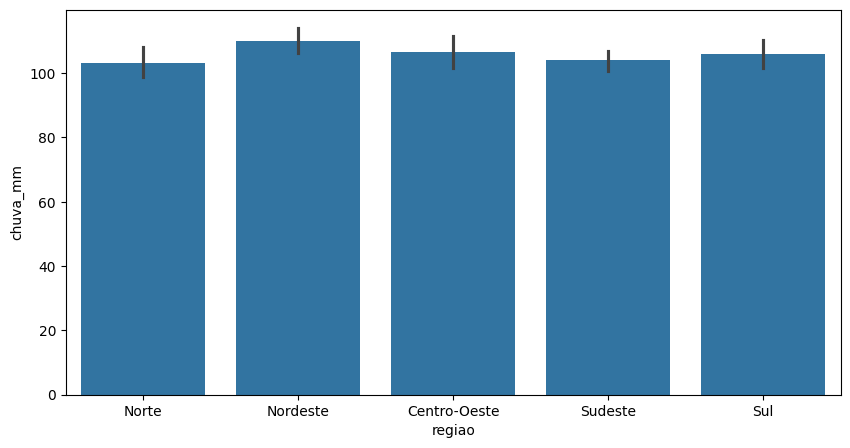

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(data=df,
            x="regiao",
            y="chuva_mm",
            estimator=np.mean)
plt.show()

###Evolução da Temperatura ao Longo dos Anos

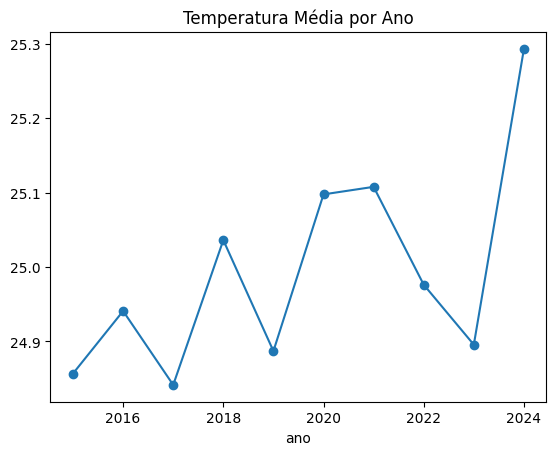

In [ ]:
temp_ano = df.groupby("ano")["temperatura_media"].mean()

temp_ano.plot(marker="o")
plt.title("Temperatura Média por Ano")
plt.show()

###Eventos Extremos por Regiões

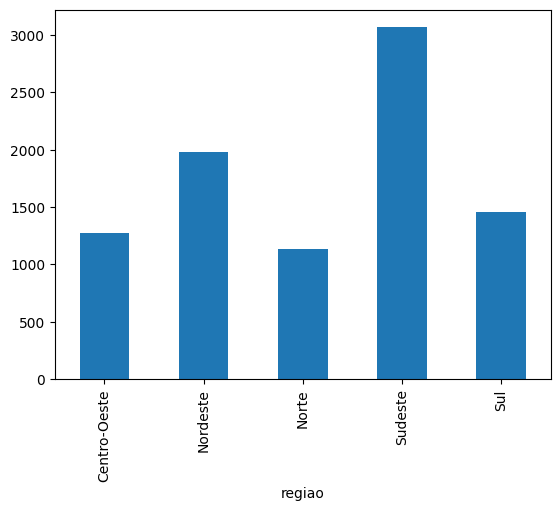

In [ ]:
eventos = df.groupby("regiao")["eventos_extremos"].sum()

eventos.plot(kind="bar")
plt.show()

###Correlação

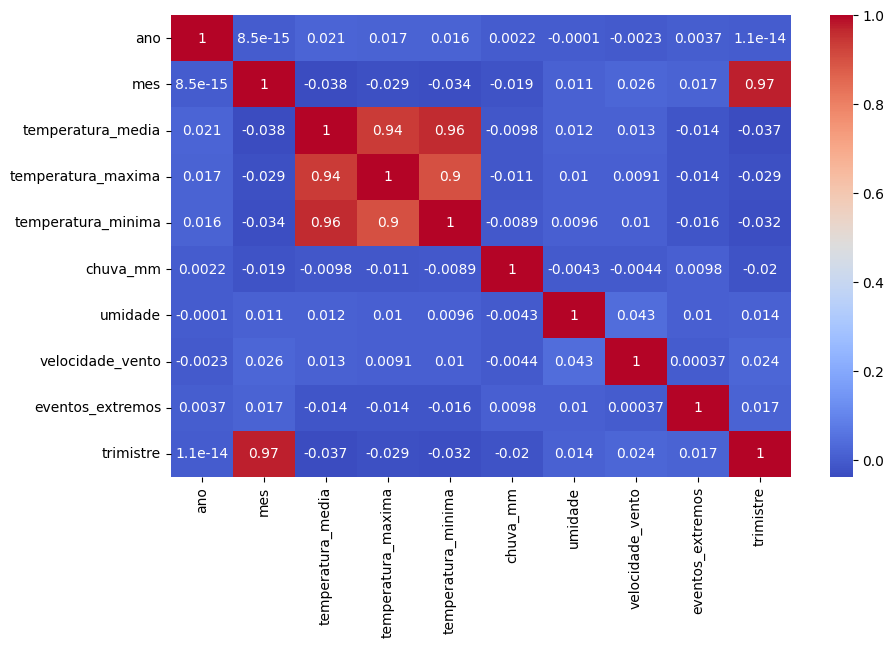

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

#Interpretação

Observou-se que determinadas regiões apresentam temperaturas médias superiores à média nacional.

Também foi identificado que regiões com maior volume de chuva tendem a apresentar maiores índices de umidade.

A análise temporal demonstra estabilidade climática com pequenas oscilações ao longo dos anos.

#Conclusão

A análise permitiu compreender o comportamento climático das diferentes regiões brasileiras.

O uso de Python, Pandas, Matplotlib e Seaborn possibilitou a construção de indicadores relevantes e visualizações que auxiliam na tomada de decisão e interpretação dos dados.